<a href="https://colab.research.google.com/github/DGP2020/r5a_ailab/blob/main/ml_lab_9july.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import numpy as np
# Load the dataset
file_path = '/content/train_energy_data_unprocessed.csv'
df = pd.read_csv(file_path)

print(f"Dataset '{file_path}' loaded successfully.\n")


df.info()

print(df.head())
print(df.tail())

Dataset '/content/train_energy_data_unprocessed.csv' loaded successfully.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        950 non-null    object 
 1   Square Footage       951 non-null    object 
 2   Number of Occupants  950 non-null    object 
 3   Appliances Used      950 non-null    object 
 4   Average Temperature  950 non-null    float64
 5   Day of Week          950 non-null    object 
 6   Energy Consumption   950 non-null    float64
dtypes: float64(2), object(5)
memory usage: 54.8+ KB
  Building Type Square Footage Number of Occupants Appliances Used  \
0   Residential         7063.0                76.0            10.0   
1    Commercial        44372.0                66.0            45.0   
2    Industrial        19255.0                37.0            17.0   
3   Residential        13265.0       

In [54]:
df.isnull().sum()

,0
Building Type,50
Square Footage,49
Number of Occupants,50
Appliances Used,50
Average Temperature,50
Day of Week,50
Energy Consumption,50


In [52]:
# Create a copy of the original DataFrame to preserve its state before preprocessing
raw_df = df.copy()

In [57]:

# 2. Impute numerical target/feature missing values with median
df['Average Temperature'] = df['Average Temperature'].fillna(df['Average Temperature'].median())
df['Energy Consumption'] = df['Energy Consumption'].fillna(df['Energy Consumption'].median())

# 3. Impute categorical missing values with the most frequent value (mode)
df['Building Type'] = df['Building Type'].fillna(df['Building Type'].mode()[0])
df['Day of Week'] = df['Day of Week'].fillna(df['Day of Week'].mode()[0])
df.isnull().sum()

,0
Building Type,0
Square Footage,49
Number of Occupants,50
Appliances Used,50
Average Temperature,0
Day of Week,0
Energy Consumption,0


In [58]:
df.duplicated().sum()

np.int64(0)

In [64]:
# Using the IQR method to cap outliers in 'Energy Consumption'
Q1 = df['Energy Consumption'].quantile(0.25)
Q3 = df['Energy Consumption'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap outliers to the upper and lower bounds
df['Energy Consumption'] = np.clip(df['Energy Consumption'], lower_bound, upper_bound)
df.sample(4)

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
773,Residential,9320.0,40.0,44.0,21.16,Weekend,3140.20
274,Industrial,NaN,76.0,12.0,10.29,Weekend,5241.91
31,Residential,46749.0,22.0,36.0,15.41,Weekend,4700.42
758,Residential,6276.0,75.0,36.0,33.11,Weekend,3118.23


In [68]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np

# Initialize scalers
min_max_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

# Handle 'Square Footage': convert to numeric, then fill NaNs, then scale
# First, convert 'Square Footage' to numeric, coercing errors (like 'ERROR' strings) to NaN
df['Square Footage'] = pd.to_numeric(df['Square Footage'], errors='coerce')
# Then, fill any NaNs (which were originally 'ERROR' or other non-numeric values)
# The median imputation is consistent with previous steps for numerical columns.
df['Square Footage'] = df['Square Footage'].fillna(df['Square Footage'].median())
# Now apply Min-Max normalization to the cleaned and imputed 'Square Footage'
df['Square Footage_MinMax'] = min_max_scaler.fit_transform(df[['Square Footage']])

# Example: Standardization (Z-score scaling) on 'Average Temperature'
# 'Average Temperature' was already handled in cell KtyUFSVOLrau (imputed NaNs, implicitly numeric based on its initial float64 dtype)
df['Avg_Temp_Standardized'] = standard_scaler.fit_transform(df[['Average Temperature']])

In [69]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

# Identify columns with a correlation threshold above 0.85 to drop redundant features
corr_matrix = numeric_df.corr()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

print(f"Features recommended to drop due to high collinearity: {to_drop}")
# df.drop(columns=to_drop, inplace=True)

Features recommended to drop due to high collinearity: ['Square Footage_MinMax', 'Avg_Temp_Standardized']


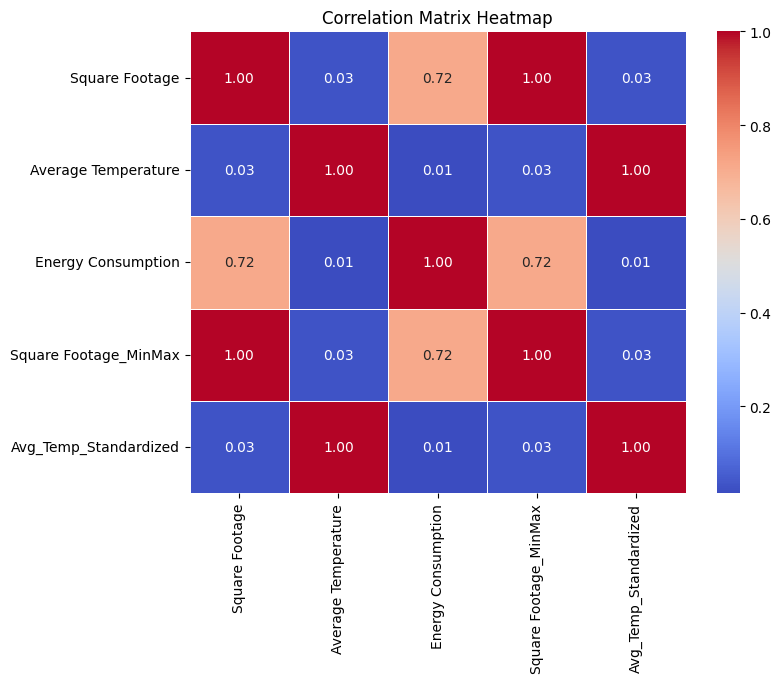

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate pairwise correlation matrix
corr = df.select_dtypes(include=[np.number]).corr()

# Generate and display the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [71]:
# 14. Handle Noisy Data: Replace 'ERROR' string tokens with NaN
cols_to_clean = ['Square Footage', 'Number of Occupants', 'Appliances Used']
for col in cols_to_clean:
    df[col] = df[col].replace('ERROR', np.nan)

# 13. Convert Data Types: Safely convert objects to float/numeric structures
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill the newly exposed NaNs with their column medians
for col in cols_to_clean:
    df[col] = df[col].fillna(df[col].median())

In [72]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = df.drop(columns=['Energy Consumption'])
y = df['Energy Consumption']

# Perform an 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40)
print(f"Train set size: {X_train.shape}, Test set size: {X_test.shape}")

Train set size: (700, 8), Test set size: (300, 8)


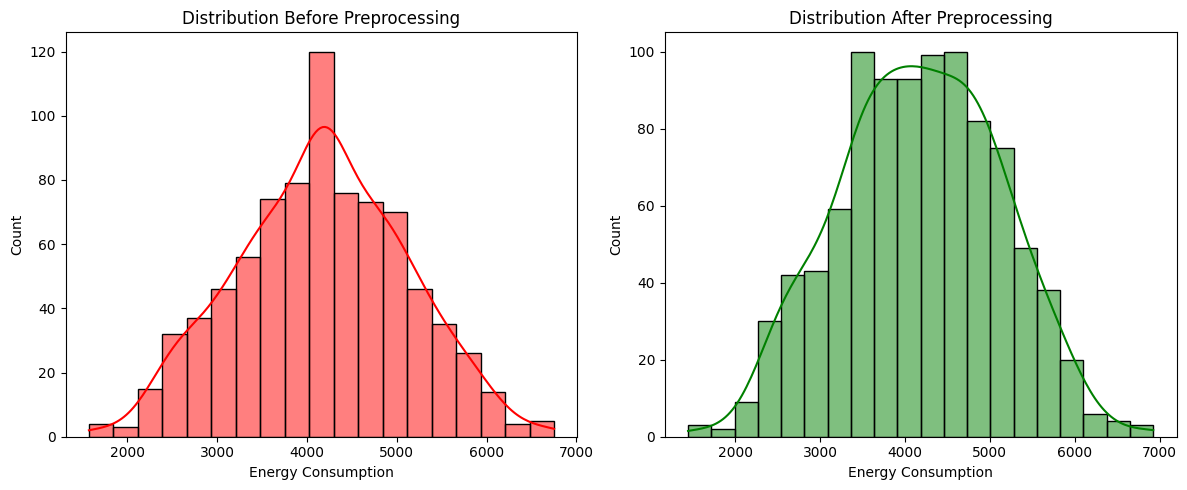

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Assuming 'raw_df' preserves the initial state before outlier capping
sns.histplot(raw_df['Energy Consumption'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Distribution Before Preprocessing')

sns.histplot(df['Energy Consumption'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution After Preprocessing')

plt.tight_layout()
plt.show()

In [74]:
print("--- Raw Dataset Summary ---")
print(raw_df.describe(include='all'))

print("\n--- Cleaned Dataset Summary ---")
print(df.describe(include='all'))

--- Raw Dataset Summary ---
       Building Type  Square Footage  Number of Occupants  Appliances Used  \
count            815      815.000000           815.000000       815.000000   
unique             3             NaN                  NaN              NaN   
top      Residential             NaN                  NaN              NaN   
freq             284             NaN                  NaN              NaN   
mean             NaN    24966.028834            47.859298        25.276074   
std              NaN    14803.525804            29.688385        14.658390   
min              NaN   -44361.000000           -92.000000       -47.000000   
25%              NaN    12613.500000            23.000000        13.000000   
50%              NaN    25184.500000            47.640212        26.000000   
75%              NaN    37339.000000            72.000000        38.000000   
max              NaN    49969.000000            99.000000        49.000000   

        Average Temperature Day of 

In [75]:
# Save to disk without keeping the arbitrary dataframe index column
df.to_csv('cleaned_energy_data.csv', index=False)
print("Preprocessed dataset successfully saved!")

Preprocessed dataset successfully saved!
